### Path Finder: What are the potential paths between two nodes?
### This pipeline can be used to get a ranked path between A and B given a set of paths.

In [15]:
import sys
import os
sys.path.append('../TCT/')
import TCT
from TCT import translator_kpinfo
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_query
from TCT import TCT_pathfinder

import requests

In [16]:
APInames, metaKG, Translator_KP_info= translator_metakg.load_translator_resources()

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'url': '/sipr'}


In [17]:
# This is an example of selecting a list of APIs for the neighborhood finder. The user can modify this list to include the APIs they want to use. The APIs in this list are the ones that will be used to find the neighborhood of a given node in the knowledge graph. The user can also modify the list of predicates to use for finding the neighborhood. The predicates in this list are the ones that will be used to find the neighborhood of a given node in the knowledge graph. 
# The user can also modify the list of categories to use for finding the neighborhood. 
# The categories in this list are the ones that will be used to find the neighborhood of a given node in the knowledge graph.
# if selected_APIlist is empty, use all APIs in APInames
selected_APIlist = ['Retriever',
                    'Clinical Trials KP - TRAPI 1.5.0',
                    'Drug Approvals KP - TRAPI 1.5.0',
                    'Genetics Data Provider for NCATS Biomedical Translator Reasoners',
                    'Microbiome KP - TRAPI 1.5.0',
                    'MolePro',
                    'COHD TRAPI',
                    'RTX KG2 - TRAPI 1.5.0',
                    'Text Mined Cooccurrence API',
                    'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0',
                    'CATRAX Pharmacogenomics KP - TRAPI 1.5.0',
                    ]

# add Automat API to the selected API list if it is not already in the list
for api in APInames:
    if 'Automat' in api and api not in selected_APIlist:
        selected_APIlist.append(api)

#selected_APIlist = ['Retriever']

# select a list of APIs to use and a list of predicates to use
if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
#print(select_APIs)
print(selected_metaKG.shape)

All_predicates = list(set(selected_metaKG['Predicate']))
All_categories = list((set(list(set(selected_metaKG['Subject']))+list(set(selected_metaKG['Object'])))))
API_withMetaKG = list(set(selected_metaKG['API']))
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(selected_metaKG[selected_metaKG['API'] == api]['Predicate']))

(20853, 5)


In [18]:
name_resolver.lookup('RYR1', return_top_response = False)

[TranslatorNode(curie='NCBIGene:6261', label='RYR1', types=['biolink:Gene', 'biolink:GeneOrGeneProduct', 'biolink:GenomicEntity', 'biolink:ChemicalEntityOrGeneOrGeneProduct', 'biolink:PhysicalEssence', 'biolink:OntologyClass', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity', 'biolink:PhysicalEssenceOrOccurrent', 'biolink:MacromolecularMachineMixin', 'biolink:Protein', 'biolink:GeneProductMixin', 'biolink:Polypeptide', 'biolink:ChemicalEntityOrProteinOrPolypeptide'], synonyms=None, curie_synonyms=None, attributes=None, taxa=['NCBITaxon:9606']),
 TranslatorNode(curie='NCBIGene:117364638', label='RYR1', types=['biolink:Gene', 'biolink:GeneOrGeneProduct', 'biolink:GenomicEntity', 'biolink:ChemicalEntityOrGeneOrGeneProduct', 'biolink:PhysicalEssence', 'biolink:OntologyClass', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity', 'biolink:PhysicalEssenceOrOccurrent', 'biolink:MacromolecularMachineMixin', 'bi

In [30]:
#name_resolver.lookup('miR-155', only_taxa='NCBITaxon:9606')
subject_name = 'NPM1'
subject_node = name_resolver.lookup(subject_name, only_taxa='NCBITaxon:9606').curie
subject_category = name_resolver.lookup(subject_name, only_taxa='NCBITaxon:9606').types
subject_category = ["biolink:Gene"]
object_name = 'acute myeloid leukemia'
object_node = name_resolver.lookup(object_name, biolink_category='biolink:Disease').curie
object_category = name_resolver.lookup(object_name, biolink_category='biolink:Disease').types
object_category = ["biolink:Disease"]

intermediate_categories = [ 'biolink:Gene','biolink:Protein']

#name_resolver.lookup('Myelodysplastic syndrome', return_top_response=False, biolink_category='biolink:Disease')

In [33]:
object_node

'MONDO:0018874'

In [7]:
object_node

'MONDO:0004975'

NCBIGene:4869
MONDO:0018874
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-cam-kp(Trapi v1.5.0): Success!
Automat-genome-alliance(Trapi v1.5.0): Success!
Microbiome KP - TRAPI 1.5.0: Success!
Automat-hetionet(Trapi v1.5.0): Success!
Retriever: Success!
RTX KG2 - TRAPI 1.5.0: Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
MolePro: Success!
Automat-robokop(Trapi v1.5.0): Success!
Automat-monarchinitiative(Trapi v1.5.0): Success!
Genetics Data Provider for NCATS Biomedical Translator Reasoners: Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-pharos(Trapi v1.5.0): Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
Retriever: Success!
Automat-robokop(Trapi v1.5.0): Success!
Clinical Trials KP - TRAPI 1.5.0: Success!
RTX KG2 - TRAPI 1.5.0: Success!
NodeNorm does not know about these identifiers: UniProtKB:C0HMD6,orphanet:159793
Number of possible paths:  733


/Users/gqin/Github_repo/Translator_component_toolkit/TCT/TCT.py:1653: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


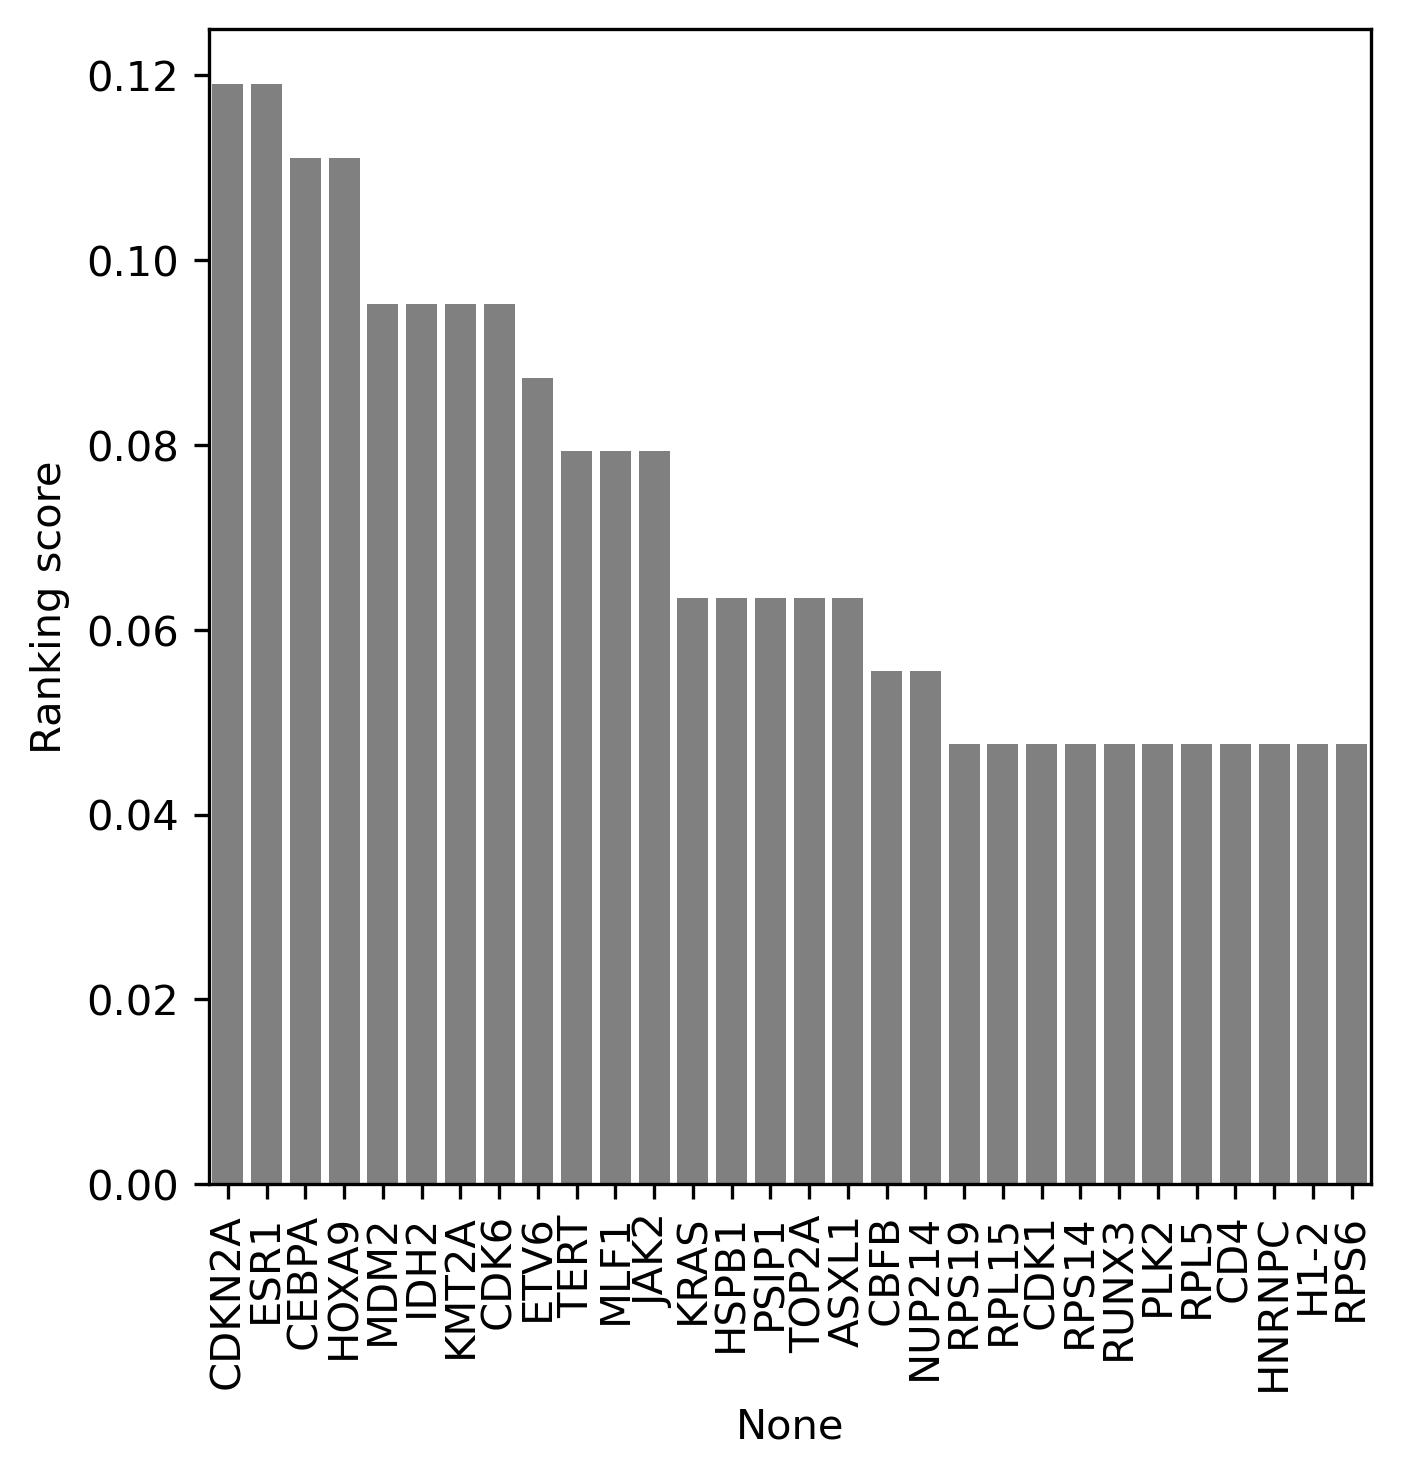

In [31]:
result = TCT.Path_finder(input_node1=subject_node, #IFNG 
                         input_node2= object_node, #COVID-19
                         intermediate_categories=intermediate_categories, 
                         APInames=select_APIs, 
                         metaKG=selected_metaKG, 
                        API_predicates=API_predicates)

In [32]:
TCT_path_finder_result = TCT_pathfinder.parse_results_for_pathfinder(subject_node, object_node, result1=result['result1'], result2=result['result2'])
# return results path_finder_result to a json file
import json
with open(f'TCT_path_finder_result__{subject_node.replace(":", "_")}__{object_node.replace(":", "_")}.json', 'w') as f:
    json.dump(TCT_path_finder_result, f, indent=4)

In [10]:
# visulize the paths in visulize_path_finder_results.html

In [36]:
intermediate_categories

['biolink:Gene', 'biolink:Protein']

In [34]:
# query arax pathfinder with constraints and write response to a json file
import time
start_time = time.time()
result_arax = TCT_pathfinder.query_arax_pathfinder_with_constraints(subject_node, 
                                                                    subject_category,
                                                                    object_node, 
                                                                    object_category, 
                                                                    constraints=intermediate_categories)
end_time = time.time()
arax_execution_time = end_time - start_time
if result_arax.json()['message'].get('auxiliary_graphs') is not None:
    Number_of_paths_ARAX_constrained = len(result_arax.json()['message']['auxiliary_graphs'])
else:    
    Number_of_paths_ARAX_constrained = 0
print(f"ARAX execution time with constraints: {arax_execution_time} seconds")
print(f"Number of paths ARAX with constraints: {Number_of_paths_ARAX_constrained}")
import json
with open('arax_pathfinder_response_'+subject_name.replace(":", "_")+'_'+object_name.replace(":", "_")+'with_constraints.json', 'w') as f:
    json.dump(result_arax.json()['message'], f, indent=4)

ARAX execution time with constraints: 116.92817616462708 seconds
Number of paths ARAX with constraints: 500


In [12]:
intermediate_categories

['biolink:Gene', 'biolink:Protein']

In [35]:
# run aragorn pathfinder without constraints and write response to a json file
import time
start_time = time.time()
aragorn_response = TCT_pathfinder.query_aragorn_pathfinder_with_constraints(subject_node, 
                                                           subject_category, 
                                                           object_node, 
                                                           object_category, 
                                                           constraints=intermediate_categories)
# write response to a json file
import json
if 'message' in aragorn_response.json():
    with open('aragorn_pathfinder_response_'+subject_name.replace(":", "_")+'_'+object_name.replace(":", "_")+'constrained.json', 'w') as f:
        json.dump(aragorn_response.json()['message'], f, indent=4)
end_time = time.time()
aragorn_execution_time = end_time - start_time
Number_of_paths_aragorn = len(aragorn_response.json()['message']['auxiliary_graphs'])
print(f"Aragorn execution time: {aragorn_execution_time} seconds")
print(f"Number of paths Aragorn: {Number_of_paths_aragorn}")

Aragorn execution time: 14.577237129211426 seconds
Number of paths Aragorn: 500


In [ ]:
#name_resolver.lookup('miR-155', only_taxa='NCBITaxon:9606')
subject_name = 'Revumenib'
subject_node = name_resolver.lookup(subject_name).curie
subject_category = name_resolver.lookup(subject_name).types
subject_category = ["biolink:Drug", "biolink:SmallMolecule", "biolink:ChemicalSubstance"]
object_name = 'acute myeloid leukemia'
object_node = name_resolver.lookup(object_name, biolink_category='biolink:Disease').curie
object_category = name_resolver.lookup(object_name, biolink_category='biolink:Disease').types
object_category = ["biolink:Disease"]


In [ ]:
# run aragorn pathfinder without constraints and write response to a json file
start_time = time.time()
aragorn_response = TCT_pathfinder.query_aragorn_pathfinder(subject_node, 
                                                           subject_category, 
                                                           object_node, 
                                                           object_category)
# write response to a json file
import json
if 'message' in aragorn_response.json():
    with open('aragorn_pathfinder_response_'+subject_name.replace(":", "_")+'_'+object_name.replace(":", "_")+'.json', 'w') as f:
        json.dump(aragorn_response.json()['message'], f, indent=4)
end_time = time.time()
aragorn_execution_time = end_time - start_time
Number_of_paths_aragorn = len(aragorn_response.json()['message']['auxiliary_graphs'])
print(f"Aragorn execution time: {aragorn_execution_time} seconds")
print(f"Number of paths Aragorn: {Number_of_paths_aragorn}")

Aragorn execution time: 5.328175783157349 seconds
Number of paths Aragorn: 22


In [ ]:
arax_response = TCT_pathfinder.query_arax_pathfinder(subject_node, 'biolink:SmallMolecule', object_node, 'biolink:Disease')
# write response to a json file
import json
with open('arax_pathfinder_response_'+subject_node.replace(":", "_")+'_'+object_node.replace(":", "_")+'.json', 'w') as f:
    json.dump(arax_response.json()['message'], f, indent=4)
arax_execution_time = end_time - start_time
if arax_response.json()['message'].get('auxiliary_graphs') is not None:
    Number_of_paths_ARAX = len(arax_response.json()['message']['auxiliary_graphs'])
else:    
    Number_of_paths_ARAX = 0
print(f"ARAX execution time: {arax_execution_time} seconds")
print(f"Number of paths ARAX: {Number_of_paths_ARAX}")


ARAX execution time: 5.328175783157349 seconds
Number of paths ARAX: 500


# link to the UI
https://ui.ci.transltr.io/

# link to TCT results visulization
./visulize_path_finder_results.html
